# F12: Fold Dimensionality

Alignment is a fold, not a wall. K₅₀ = how many independent directions needed to account for 50% of the total alignment shift (SVD of aligned − base hidden states).

**Data**: `data/fold_svd_{family}.npz` — precomputed via `scripts/compute_fold_svd.py`.  
**Figures**: `figures/F12_fold_mobius.png`, `figures/F12_fold_dimensionality_talk.png`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

## 1. Load SVD data and K₅₀ summary

In [2]:
import pandas as pd

SVD_FAMILIES = ['pythia', 'llama', 'tulu', 'tulu_sft', 'zephyr', 'olmo']
svd_data = {}

for fam in SVD_FAMILIES:
    d = np.load(f'../data/fold_svd_{fam}.npz')
    S = d['S']
    cumvar = np.cumsum(S**2) / np.sum(S**2)
    k50 = int(np.searchsorted(cumvar, 0.5)) + 1
    svd_data[fam] = {'S': S, 'U': d['U'], 'Vt': d['Vt'], 'cumvar': cumvar, 'k50': k50,
                      'top1_pct': S[0]**2 / (S**2).sum() * 100}
    print(f'{fam:12s}  K50={k50:2d}  top1={svd_data[fam]["top1_pct"]:.1f}%  n_prompts={d["U"].shape[0]}')

# Full summary from fold_rank CSVs
rank_df = pd.read_csv('../data/fold_rank_summary.csv')
rank_df[['family', 'layer', 'k_50', 'top1_var_pct']].sort_values('k_50')

pythia        K50= 1  top1=51.0%  n_prompts=71
llama         K50= 8  top1=27.4%  n_prompts=71
tulu          K50= 7  top1=27.3%  n_prompts=71
tulu_sft      K50= 9  top1=21.4%  n_prompts=71
zephyr        K50= 6  top1=31.1%  n_prompts=71
olmo          K50=13  top1=18.4%  n_prompts=71


,family,layer,k_50,top1_var_pct
0,pythia,26,2,48.6
1,amber,26,3,44.4
2,olmo-tiny,12,3,38.6
3,zephyr,26,5,30.7
4,qwen,23,6,27.2
5,llama,16,7,21.1
6,tulu,26,7,28.3
7,qwen-tiny,12,8,20.8
8,smol,16,9,20.9
9,olmo,8,13,13.1


## 2. Cumulative variance overlay (talk figure)

Line chart showing how quickly each family's fold is captured by adding directions. Where the curve crosses 50% = K₅₀.

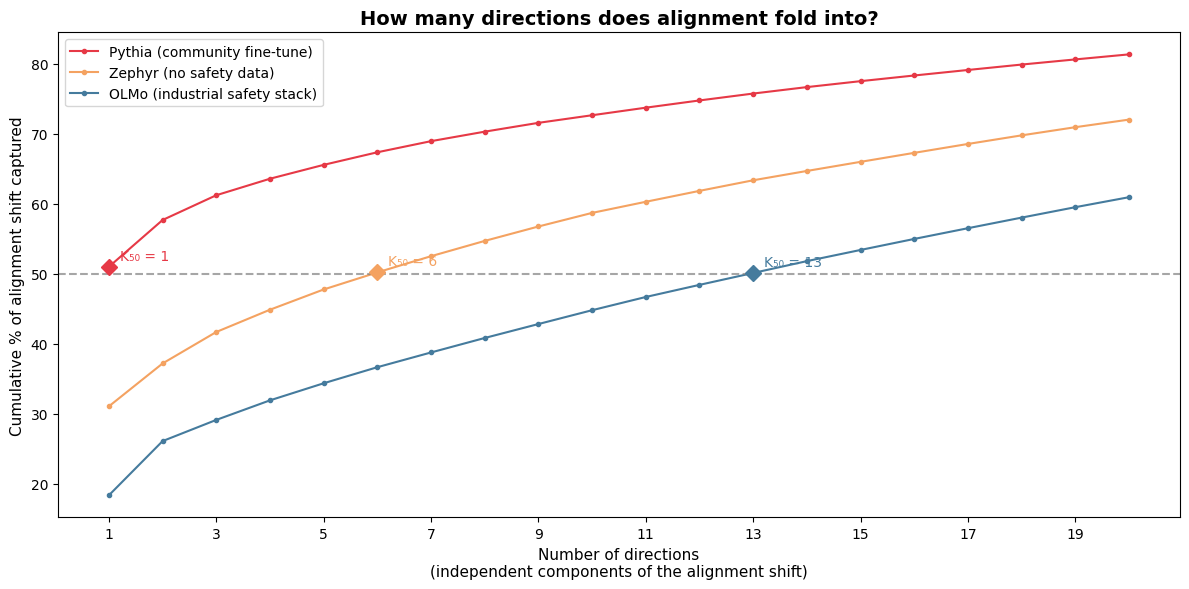

In [3]:
PLOT_FAMILIES = ['pythia', 'zephyr', 'olmo']
LABELS = {
    'pythia': 'Pythia (community fine-tune)',
    'zephyr': 'Zephyr (no safety data)',
    'olmo': 'OLMo (industrial safety stack)',
}
COLORS = {'pythia': '#e63946', 'zephyr': '#f4a261', 'olmo': '#457b9d'}

N = 20
fig, ax = plt.subplots(figsize=(12, 6))

for fam in PLOT_FAMILIES:
    cv = svd_data[fam]['cumvar']
    k50 = svd_data[fam]['k50']
    dirs = np.arange(1, min(N, len(cv)) + 1)
    ax.plot(dirs, cv[:N] * 100, '-o', color=COLORS[fam], label=LABELS[fam], linewidth=1.5, markersize=3)
    ax.plot(k50, cv[k50 - 1] * 100, 'D', color=COLORS[fam], markersize=8, zorder=5)
    ax.annotate(f'K₅₀ = {k50}', (k50, cv[k50 - 1] * 100), textcoords='offset points',
                xytext=(8, 5), fontsize=10, color=COLORS[fam])

ax.axhline(50, linestyle='--', color='gray', alpha=0.7)
ax.set_xlabel('Number of directions\n(independent components of the alignment shift)', fontsize=11)
ax.set_ylabel('Cumulative % of alignment shift captured', fontsize=11)
ax.set_title('How many directions does alignment fold into?', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(range(1, N + 1, 2))
plt.tight_layout()
plt.savefig('../figures/F12_fold_dimensionality_talk.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Möbius strip figure (talk figure)

The libidinal band crumpled into alignment. Base Möbius strip topology = Lyotard's libidinal band. Fold perturbations = real SVD singular values (K₅₀ modes, amplitude = sqrt of variance fraction).

In [4]:
def plot_mobius_figure(panels, title, subtitle, filename, figsize=(19, 8)):
    """
    Plot Möbius strip fold figure.
    
    panels: list of (svd_key_or_'base', panel_label, n_folds)
        svd_key must be a key in svd_data dict, or 'base' for unfolded band.
    """
    fig = plt.figure(figsize=figsize)
    
    np.random.seed(42)
    n_max = 15
    fold_phases = np.random.uniform(0, 2 * np.pi, n_max)
    
    n_u, n_v = 300, 50
    u = np.linspace(0, 2 * np.pi, n_u)
    v = np.linspace(-0.5, 0.5, n_v)
    U_grid, V_grid = np.meshgrid(u, v)
    
    ELEV, AZIM = 25, -55
    
    for idx, (fam, label, k) in enumerate(panels):
        if fam != 'base':
            S = svd_data[fam]['S']
            var_frac = S**2 / (S**2).sum()
        
        half_u = U_grid / 2
        R = 1 + V_grid * np.cos(half_u)
        X = R * np.cos(U_grid)
        Y = R * np.sin(U_grid)
        Z = V_grid * np.sin(half_u)
        
        perturbation_signed = np.zeros_like(X)
        
        if fam != 'base':
            fold_scale = 0.25
            for i in range(k):
                amp = np.sqrt(var_frac[i]) * fold_scale
                freq = (i + 1) * 2
                wave = np.sin(freq * U_grid + fold_phases[i])
                perturbation = amp * wave
                perturbation_signed += perturbation
                X += perturbation * np.cos(U_grid) * 0.5
                Y += perturbation * np.sin(U_grid) * 0.5
                Z += perturbation * 0.7
        
        ax = fig.add_subplot(1, len(panels), idx + 1, projection='3d')
        
        if fam == 'base':
            ax.plot_surface(X, Y, Z, color='#d4c5a9', linewidth=0, antialiased=True,
                            alpha=0.35, rstride=1, cstride=1, edgecolor='none')
            ax.plot_wireframe(X, Y, Z, rstride=10, cstride=12, color='#8b7d6b',
                              linewidth=0.4, alpha=0.35)
        else:
            pmax = max(abs(perturbation_signed.min()), abs(perturbation_signed.max()))
            norm = TwoSlopeNorm(vmin=-pmax, vcenter=0, vmax=pmax)
            colors = cm.RdBu_r(norm(perturbation_signed))
            ax.plot_surface(X, Y, Z, facecolors=colors, linewidth=0, antialiased=True,
                            alpha=0.9, rstride=1, cstride=1, edgecolor='none', shade=False)
            ax.plot_wireframe(X, Y, Z, rstride=15, cstride=20, color='#333333',
                              linewidth=0.2, alpha=0.3)
        
        ax.set_title(label, fontsize=11, fontweight='normal', pad=10)
        ax.view_init(elev=ELEV, azim=AZIM)
        ax.set_box_aspect([1, 1, 0.45])
        ax.set_axis_off()
        ax.set_xlim(-1.8, 1.8)
        ax.set_ylim(-1.8, 1.8)
        ax.set_zlim(-0.8, 0.8)
    
    fig.suptitle(title, fontsize=17, fontweight='bold', y=0.995)
    fig.text(0.5, 0.945, subtitle, ha='center', fontsize=12)
    fig.text(0.5, 0.91,
             'Each fold = one independent direction of the alignment shift · '
             'Fold depth = share of total shift · Red/blue = peaks and valleys',
             ha='center', fontsize=10, style='italic', color='#444444')
    fig.text(0.5, 0.02,
             'Fold count and depth from SVD of (aligned − base) hidden states across 71 prompts.\n'
             'K₅₀ = number of independent directions needed to account for 50% of the total alignment shift.',
             ha='center', fontsize=9, color='#555555')
    
    plt.subplots_adjust(wspace=-0.08, top=0.79, bottom=0.08)
    fig.savefig(f'../figures/{filename}', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved figures/{filename}')

### 3a. Primary talk figure: Base → Zephyr → OLMo

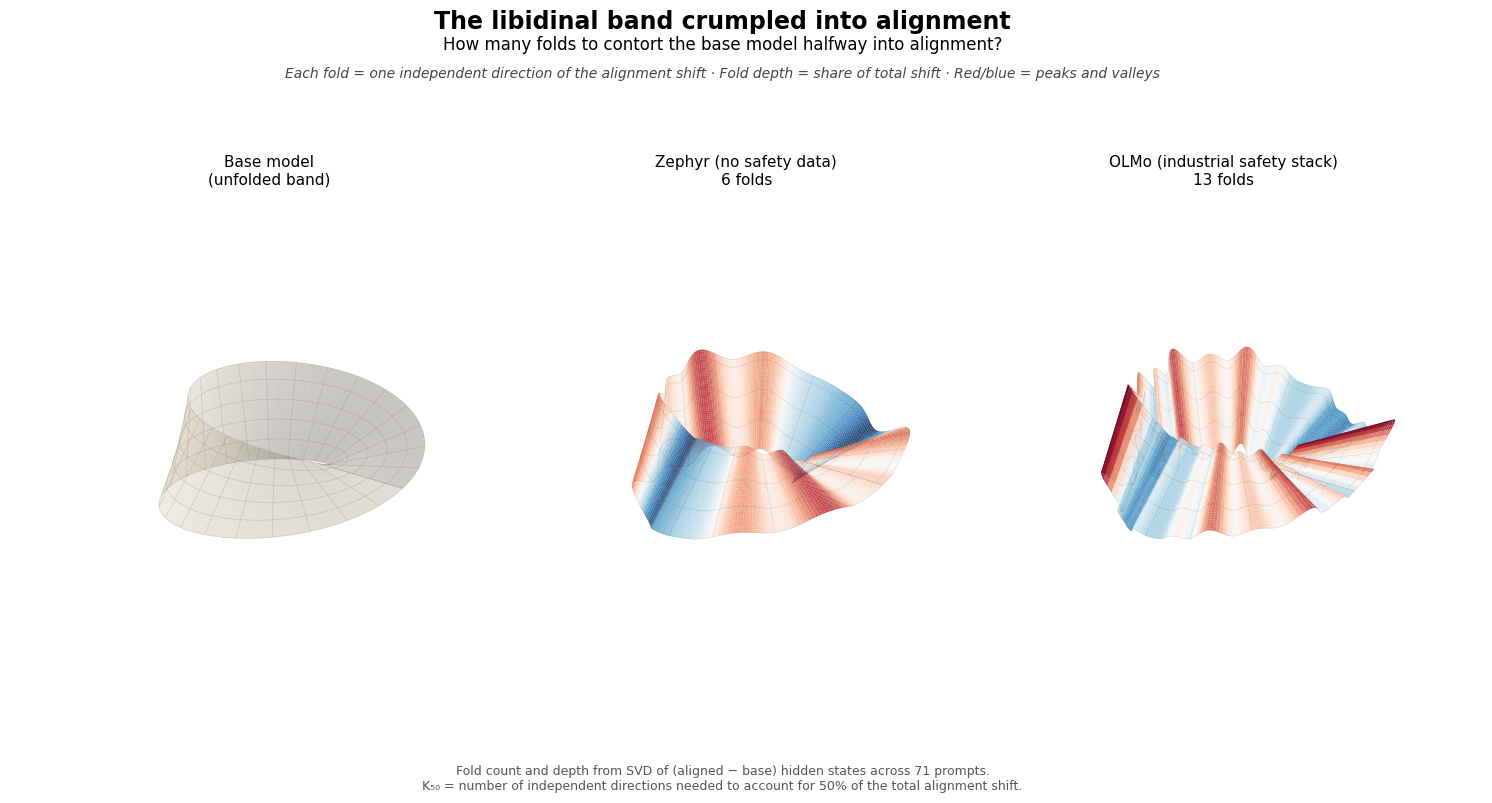

Saved figures/F12_fold_mobius.png


In [5]:
plot_mobius_figure(
    panels=[
        ('base', 'Base model\n(unfolded band)', 0),
        ('zephyr', 'Zephyr (no safety data)\n6 folds', 6),
        ('olmo', 'OLMo (industrial safety stack)\n13 folds', 13),
    ],
    title='The libidinal band crumpled into alignment',
    subtitle='How many folds to contort the base model halfway into alignment?',
    filename='F12_fold_mobius.png',
)

### 3b. Same-base comparison: Tulu SFT → Tulu DPO → Llama Instruct

All three share `meta-llama/Llama-3.1-8B` as base. Finding: DPO *concentrates* the fold (SFT 9 → DPO 7), it doesn't add new creases.

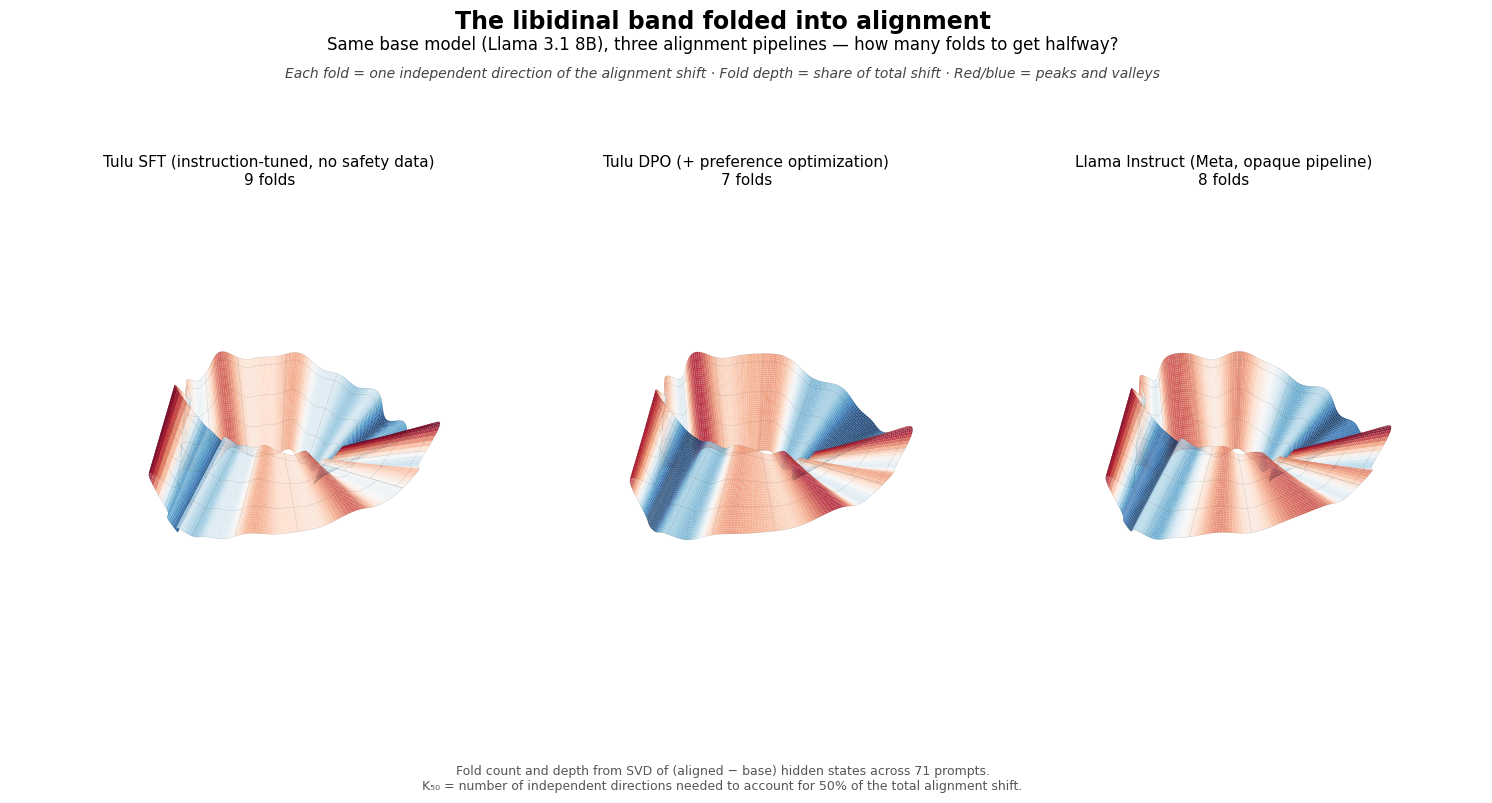

Saved figures/F12_fold_mobius_llama_tulu.png


In [6]:
plot_mobius_figure(
    panels=[
        ('tulu_sft', 'Tulu SFT (instruction-tuned, no safety data)\n9 folds', 9),
        ('tulu', 'Tulu DPO (+ preference optimization)\n7 folds', 7),
        ('llama', 'Llama Instruct (Meta, opaque pipeline)\n8 folds', 8),
    ],
    title='The libidinal band folded into alignment',
    subtitle='Same base model (Llama 3.1 8B), three alignment pipelines — how many folds to get halfway?',
    filename='F12_fold_mobius_llama_tulu.png',
)

## 4. Fold-as-path figure (3D)

Each segment = one SVD direction, length = singular value. Projected into 3D via U matrix. The path geometry is a schematic — segment lengths are real data, angles are projection artifacts.

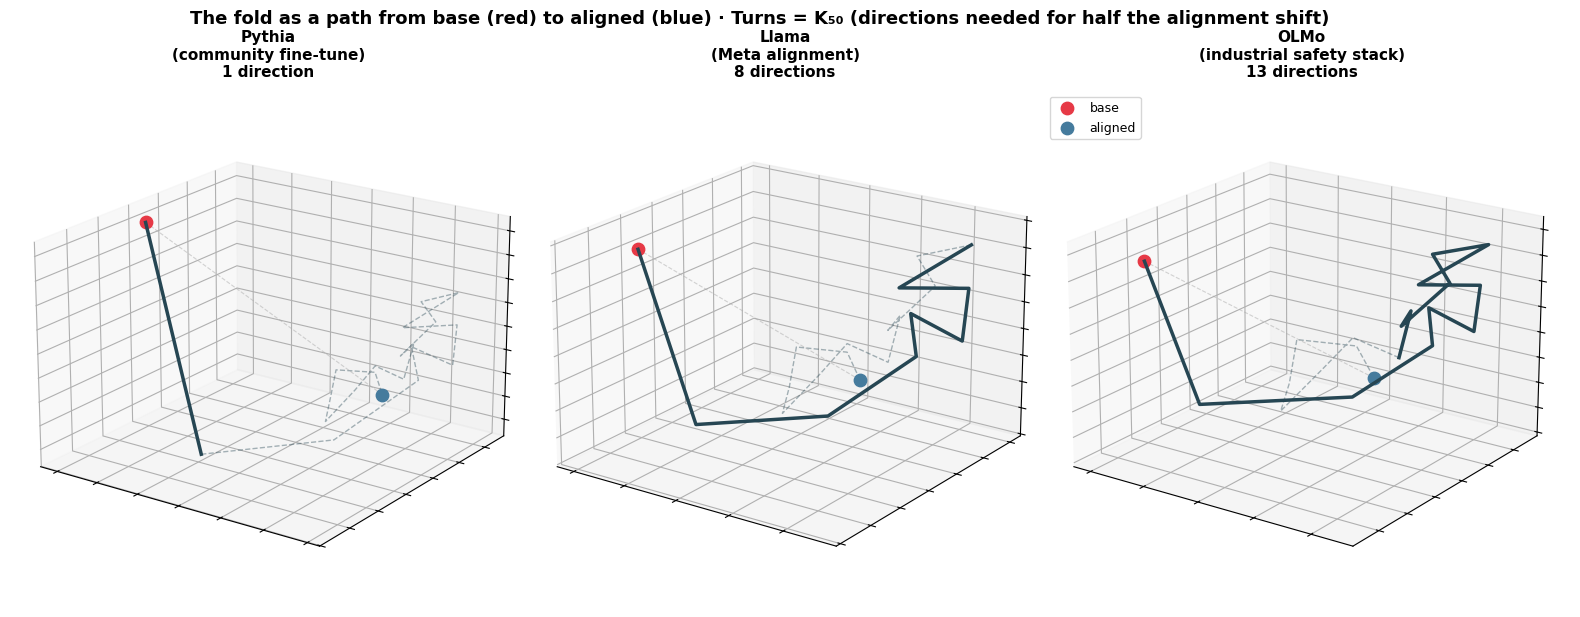

In [7]:
PATH_FAMILIES = ['pythia', 'llama', 'olmo']
PATH_LABELS = {
    'pythia': 'Pythia\n(community fine-tune)\n1 direction',
    'llama': 'Llama\n(Meta alignment)\n8 directions',
    'olmo': 'OLMo\n(industrial safety stack)\n13 directions',
}

fig = plt.figure(figsize=(20, 7))

np.random.seed(42)
n_dirs = 20
proj_angles = np.random.uniform(0, 2 * np.pi, (n_dirs, 2))

for idx, fam in enumerate(PATH_FAMILIES):
    S = svd_data[fam]['S']
    k50 = svd_data[fam]['k50']
    n = min(n_dirs, len(S))
    total = S[:n].sum()
    lengths = S[:n] / total
    
    # Build 3D path using random angles (same seed for all families)
    coords = np.zeros((n + 1, 3))
    for i in range(n):
        theta, phi = proj_angles[i]
        coords[i + 1] = coords[i] + lengths[i] * np.array([
            np.sin(theta) * np.cos(phi),
            np.sin(theta) * np.sin(phi),
            np.cos(theta)
        ])
    
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    
    # Path
    ax.plot(coords[:k50+1, 0], coords[:k50+1, 1], coords[:k50+1, 2],
            '-', color='#264653', linewidth=2.5, zorder=5)
    if k50 < n:
        ax.plot(coords[k50:, 0], coords[k50:, 1], coords[k50:, 2],
                '--', color='#264653', linewidth=1, alpha=0.4)
    
    # Dashed line from base to aligned
    ax.plot([coords[0, 0], coords[n, 0]], [coords[0, 1], coords[n, 1]],
            [coords[0, 2], coords[n, 2]], '--', color='#aaa', linewidth=0.8, alpha=0.5)
    
    # Endpoints
    ax.scatter(*coords[0], color='#e63946', s=80, zorder=10, label='base')
    ax.scatter(*coords[n], color='#457b9d', s=80, zorder=10, label='aligned')
    
    ax.set_title(PATH_LABELS[fam], fontsize=11, fontweight='bold', pad=10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.tick_params(length=0)
    ax.view_init(elev=20, azim=-55)
    ax.set_box_aspect([1, 1, 0.7])

ax.legend(loc='upper left', fontsize=9)
fig.suptitle('The fold as a path from base (red) to aligned (blue) · '
             'Turns = K₅₀ (directions needed for half the alignment shift)',
             fontsize=13, fontweight='bold', y=0.98)
plt.subplots_adjust(wspace=0.0, top=0.88)
plt.savefig('../figures/F12_fold_as_path_3d.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. DPO concentrates the fold (Tulu finding)

SFT alone: K₅₀ = 9 (diffuse). Adding DPO: K₅₀ = 7 (concentrated). DPO doesn't add new fold directions — it sharpens existing ones.

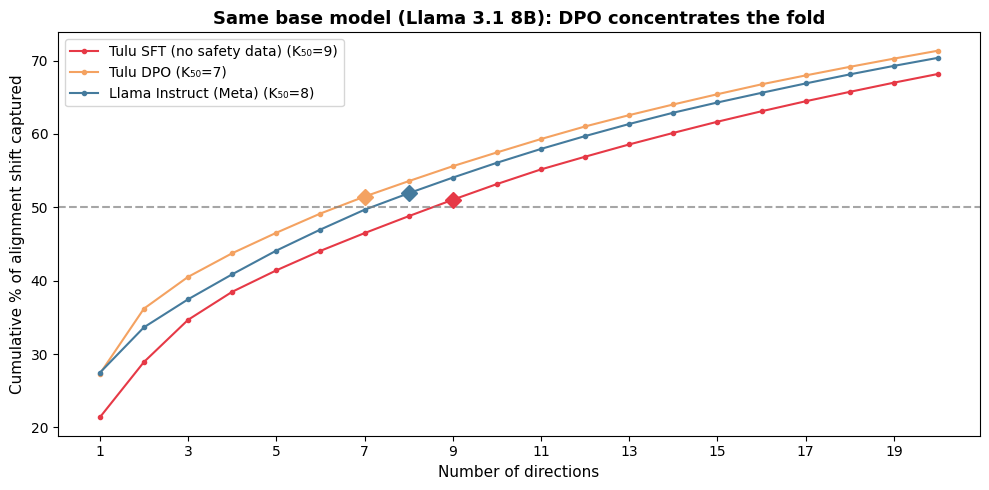

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

TULU_COMPARE = {
    'tulu_sft': ('Tulu SFT (no safety data)', '#e63946'),
    'tulu': ('Tulu DPO', '#f4a261'),
    'llama': ('Llama Instruct (Meta)', '#457b9d'),
}

N = 20
for fam, (label, color) in TULU_COMPARE.items():
    cv = svd_data[fam]['cumvar']
    k50 = svd_data[fam]['k50']
    dirs = np.arange(1, min(N, len(cv)) + 1)
    ax.plot(dirs, cv[:N] * 100, '-o', color=color, label=f'{label} (K₅₀={k50})',
            linewidth=1.5, markersize=3)
    ax.plot(k50, cv[k50 - 1] * 100, 'D', color=color, markersize=8, zorder=5)

ax.axhline(50, linestyle='--', color='gray', alpha=0.7)
ax.set_xlabel('Number of directions', fontsize=11)
ax.set_ylabel('Cumulative % of alignment shift captured', fontsize=11)
ax.set_title('Same base model (Llama 3.1 8B): DPO concentrates the fold',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(range(1, N + 1, 2))
plt.tight_layout()
plt.show()